# Exploratory Data Analysis - Descriptive Statistics in Practice

We take a real, messy retail dataset and walk through every concept we, in the following order:

1. Understanding data & variable types (categorical vs. quantitative; nominal, ordinal, interval, ratio)
2. Detecting and **treating missing values** (mean / median / mode, and *why* you'd pick one over another)
3. **Univariate analysis** - distribution of a single categorical variable
4. **Univariate analysis** - distribution of a single quantitative variable (center, spread, five-number summary, outliers, deciles/percentiles)
5. **Multivariate analysis** - relationships between two variables (C -> C, C -> Q, Q -> Q)
6. A closing note on correlation vs. causation

## 0. The Dataset

We use the **BigMart Sales** dataset, a real, publicly released retail dataset
(originally from an Analytics Vidhya hackathon) describing products sold across
10 BigMart outlets in different cities in 2013.

It's a good teaching dataset because it naturally contains:
- A mix of **categorical** variables (item type, fat content, outlet size, outlet type, ...)
- A mix of **quantitative** variables (item weight, price, visibility, sales, ...)
- **Genuine missing values** in two columns, one quantitative and one categorical, which is
  exactly what we need to demonstrate mean / median / mode imputation.

**Data dictionary**

| Column | Description |
|---|---|
| Item_Identifier | Unique product ID |
| Item_Weight | Weight of the product (kg) |
| Item_Fat_Content | Whether the product is "Low Fat" or "Regular" |
| Item_Visibility | % of total display area in the store allocated to this product |
| Item_Type | Category the product belongs to (Dairy, Snacks, Household, ...) |
| Item_MRP | Maximum Retail Price (list price) of the product |
| Outlet_Identifier | Unique store ID |
| Outlet_Establishment_Year | Year the store was established |
| Outlet_Size | Size of the store (Small / Medium / High) |
| Outlet_Location_Type | Tier of city the store is located in (Tier 1/2/3) |
| Outlet_Type | Grocery Store or Supermarket Type1/2/3 |
| Item_Outlet_Sales | Sales of the product at that particular outlet (our main outcome of interest) |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv("bigmart_sales.csv")
df.shape

(8523, 12)

In [2]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


## 1. Data and Variables

Each **row** is an individual (a product sold at a particular outlet) and each **column**
is a variable (a characteristic of that product/outlet combination)

Let's look at the data types pandas inferred, which is our first clue about whether a
column is categorical or quantitative.


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   str    
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   str    
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   str    
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   str    
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   str    
 9   Outlet_Location_Type       8523 non-null   str    
 10  Outlet_Type                8523 non-null   str    
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 799.2 KB


### Classifying every variable

Using the definitions:
- **Categorical**: places an individual into one of several groups (no arithmetic makes sense on it)
- **Quantitative**: takes numerical values that represent an actual measurement

And within categorical, whether it's **nominal** (no natural order) or **ordinal** (has a
natural order). Within quantitative, whether it's **interval** (no true zero) or **ratio**
(has a true zero).

| Variable | Type | Sub-type | Why |
|---|---|---|---|
| Item_Identifier | Categorical | Nominal | Just a label/ID, no order |
| Item_Weight | Quantitative | Ratio | 0 kg means no weight - true zero |
| Item_Fat_Content | Categorical | Nominal | "Low Fat" isn't higher/lower than "Regular" |
| Item_Visibility | Quantitative | Ratio | 0% visibility is an absence of visibility |
| Item_Type | Categorical | Nominal | Product category, no inherent order |
| Item_MRP | Quantitative | Ratio | 0 price means free - true zero |
| Outlet_Identifier | Categorical | Nominal | Store ID label |
| Outlet_Establishment_Year | Quantitative | Interval | Year 0 isn't "no time" - arbitrary zero |
| Outlet_Size | Categorical | **Ordinal** | Small < Medium < High has a natural order |
| Outlet_Location_Type | Categorical | **Ordinal** | Tier 1/2/3 reflects city size/ranking |
| Outlet_Type | Categorical | Nominal | Store format, no inherent order |
| Item_Outlet_Sales | Quantitative | Ratio | 0 sales means no sales - true zero |

Notice `Outlet_Establishment_Year` is quantitative but **interval**, not ratio - a useful
distinction the deck makes with temperature/dates: you can subtract two years meaningfully,
but "year 2018 is not twice as much as year 1009" the way 40 kg is twice 20 kg.


## 2. Missing Values

Real data is rarely complete. Before we can describe the distribution of any variable we
need to know *how much* of it is missing, because missing data can quietly bias every
statistic we compute afterwards.


In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct}).query("missing_count > 0")

,missing_count,missing_pct
Item_Weight,1463,17.17
Outlet_Size,2410,28.28


Two columns have missing values:
- **Item_Weight** (quantitative, ~17% missing)
- **Outlet_Size** (categorical, ~28% missing)

These are the two columns we need to treat. Everything else is complete.


### 2.1 Choosing how to fill the gaps: mean, median, or mode?

This step isn't covered in the lecture deck, but it's essential in practice. A quick rule
of thumb:

| Variable type | Typical imputation | Why |
|---|---|---|
| Quantitative, roughly symmetric distribution | **Mean** | The mean is a good summary of "center" only when there are no extreme outliers pulling it away from the bulk of the data |
| Quantitative, skewed distribution / has outliers | **Median** | The median ignores *how far* extreme values are, only their rank, so it isn't dragged around by outliers the way the mean is |
| Categorical | **Mode** | Mean/median aren't even defined for categories; the most frequent category is the only sensible "typical value" |

So before touching `Item_Weight`, we should check whether its distribution is symmetric or
skewed - that tells us whether mean or median is the safer choice.


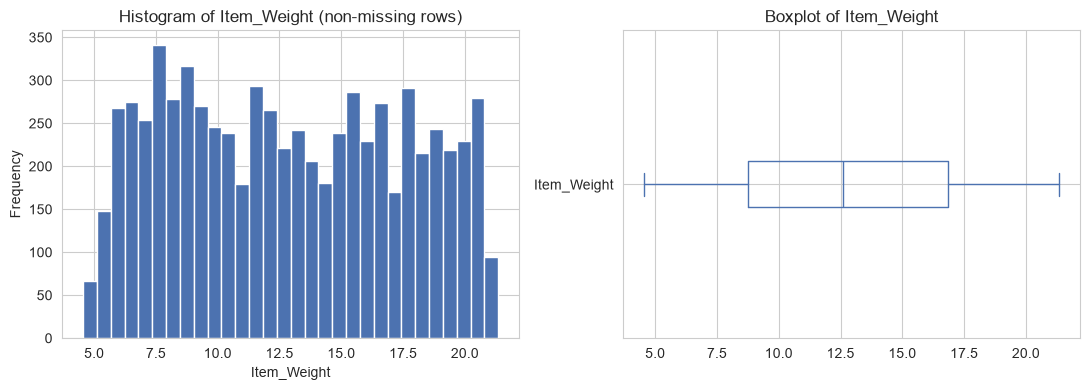

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df["Item_Weight"].dropna().plot(kind="hist", bins=30, ax=axes[0], color="#4C72B0")
axes[0].set_title("Histogram of Item_Weight (non-missing rows)")
axes[0].set_xlabel("Item_Weight")

df["Item_Weight"].dropna().plot(kind="box", ax=axes[1], vert=False, color="#4C72B0")
axes[1].set_title("Boxplot of Item_Weight")
plt.tight_layout()
plt.show()

In [6]:
weight_mean = df["Item_Weight"].mean()
weight_median = df["Item_Weight"].median()
weight_skew = df["Item_Weight"].skew()
print(f"Mean   : {weight_mean:.2f}")
print(f"Median : {weight_median:.2f}")
print(f"Skewness: {weight_skew:.3f}")

Mean   : 12.86
Median : 12.60
Skewness: 0.082


The histogram looks fairly flat/symmetric, there's no long tail and no extreme
outliers in the boxplot, and the skewness is close to 0. Mean and median are also very
close to each other (~12.86 vs ~12.60). In a case like this either would work reasonably
well; we'll use the **median** anyway since it's the safer, more general-purpose default
whenever there's any doubt and it gives up almost nothing when the data is already
symmetric.


In [7]:
df["Item_Weight"] = df["Item_Weight"].fillna(weight_median)
df["Item_Weight"].isnull().sum()

np.int64(0)

Now for `Outlet_Size`, a categorical variable. Mean/median don't apply here at all -
we look at which category occurs most often (the **mode**) and check how skewed that
distribution is before deciding.


In [8]:
df["Outlet_Size"].value_counts()

Outlet_Size
Medium    2793
Small     2388
High       932
Name: count, dtype: int64

In [9]:
outlet_size_mode = df["Outlet_Size"].mode()[0]
df["Outlet_Size"] = df["Outlet_Size"].fillna(outlet_size_mode)
print("Filled with mode:", outlet_size_mode)
df["Outlet_Size"].isnull().sum()

Filled with mode: Medium


np.int64(0)

Both columns are now fully populated. A quick sanity check across the whole dataframe:


In [11]:
df.isnull().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

### 2.2 A quick, related cleaning step

While we're treating data quality issues, it's worth noticing that `Item_Fat_Content` is
*not missing* anything, but the same category has been typed inconsistently
("Low Fat", "low fat", "LF", "Regular", "reg"). This isn't a missing-value problem, but if
we don't fix it, our categorical frequency table in the next section would wrongly treat
these as five different categories instead of two.


In [12]:
df["Item_Fat_Content"].value_counts()

Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64

In [13]:
df["Item_Fat_Content"] = df["Item_Fat_Content"].replace(
    {"low fat": "Low Fat", "LF": "Low Fat", "reg": "Regular"}
)
df["Item_Fat_Content"].value_counts()

Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64

## 3. Univariate Analysis - Categorical Variables

For a categorical variable, "distribution" means: what categories exist, and how often
does each occur? We build a **frequency distribution table** (count + percentage) and
visualize it with a bar chart and pie chart, exactly as in the deck.

Since we'll repeat this for several columns, it's worth writing one small reusable
function.


In [15]:
def describe_categorical(column):
    '''Print a frequency distribution table and plot a bar chart + pie chart.'''
    counts = df[column].value_counts()
    pct = (counts / counts.sum() * 100).round(2)
    freq_table = pd.DataFrame({"Count": counts, "Percentage": pct})
    display(freq_table)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    counts.plot(kind="bar", ax=axes[0], color="#4C72B0")
    axes[0].set_title(f"Bar Chart: {column}")
    axes[0].set_ylabel("Count")

    axes[1].pie(counts, labels=counts.index, autopct="%1.1f%%", startangle=90)
    axes[1].set_title(f"Pie Chart: {column}")
    plt.tight_layout()
    plt.show()

**Item_Fat_Content** - now cleaned to just two categories:

,Count,Percentage
Item_Fat_Content,,
Low Fat,5517,64.73
Regular,3006,35.27


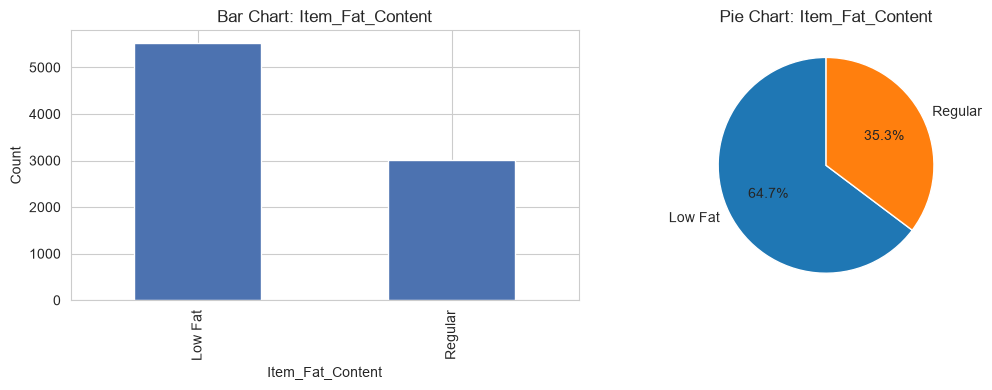

In [16]:
describe_categorical("Item_Fat_Content")

**Outlet_Size** - an ordinal categorical variable:

,Count,Percentage
Outlet_Size,,
Medium,5203,61.05
Small,2388,28.02
High,932,10.94


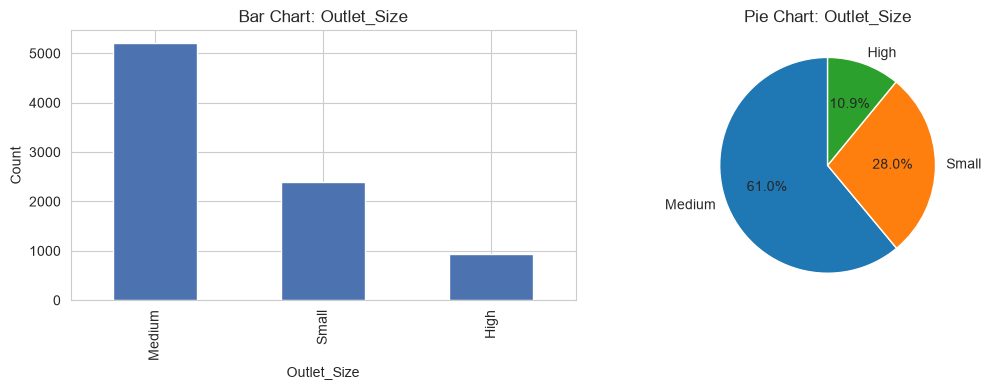

In [17]:
describe_categorical("Outlet_Size")

**Outlet_Type** - the format of the store:

,Count,Percentage
Outlet_Type,,
Supermarket Type1,5577,65.43
Grocery Store,1083,12.71
Supermarket Type3,935,10.97
Supermarket Type2,928,10.89


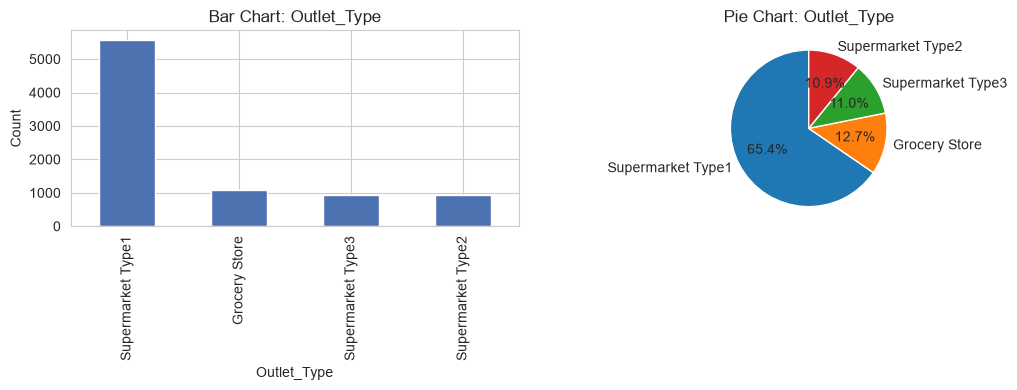

In [18]:
describe_categorical("Outlet_Type")

## 4. Univariate Analysis - Quantitative Variables

For a quantitative variable we describe its distribution with:
- A **histogram** (shape of the distribution)
- **Central tendency**: mean, median, mode
- **Dispersion**: range, variance, standard deviation, IQR
- The **five-number summary** (min, Q1, median, Q3, max) and its **boxplot**
- **Outlier detection** using Tukey's 1.5xIQR rule

Again, since we repeat this for several columns, we wrap it in one function.


In [22]:
def describe_quantitative(column):
    '''Print central tendency + dispersion stats and plot a histogram + boxplot.'''
    data = df[column]

    mean_, median_ = data.mean(), data.median()
    mode_ = data.mode()[0]
    min_, max_ = data.min(), data.max()
    range_ = max_ - min_
    var_, std_ = data.var(), data.std()
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1

    summary = pd.Series(
        {
            "Mean": mean_, "Median": median_, "Mode": mode_,
            "Min": min_, "Q1": q1, "Q3": q3, "Max": max_,
            "Range": range_, "Variance": var_, "Std Dev": std_, "IQR": iqr,
        }
    ).round(2)
    display(summary)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    data.plot(kind="hist", bins=30, ax=axes[0], color="#58C972")
    axes[0].axvline(mean_, color="red", linestyle="--", label="Mean")
    axes[0].axvline(median_, color="black", linestyle="--", label="Median")
    axes[0].set_title(f"Histogram: {column}")
    axes[0].legend()

    data.plot(kind="box", ax=axes[1], vert=False, color="#3218B1")
    axes[1].set_title(f"Boxplot: {column}")
    plt.tight_layout()
    plt.show()

**Item_Weight** (now that missing values are filled in):

Mean        12.81
Median      12.60
Mode        12.60
Min          4.56
Q1           9.31
Q3          16.00
Max         21.35
Range       16.80
Variance    17.87
Std Dev      4.23
IQR          6.69
dtype: float64

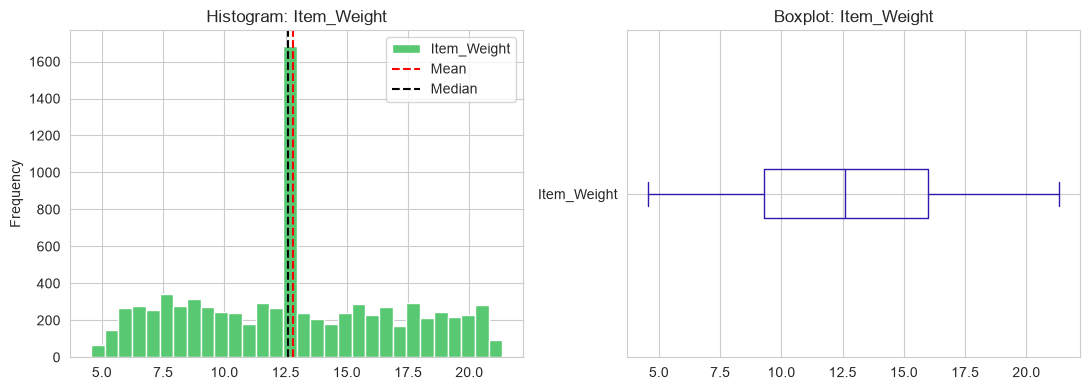

In [23]:
describe_quantitative("Item_Weight")

**Item_MRP** - the product's listed price:

Mean         140.99
Median       143.01
Mode         172.04
Min           31.29
Q1            93.83
Q3           185.64
Max          266.89
Range        235.60
Variance    3878.18
Std Dev       62.28
IQR           91.82
dtype: float64

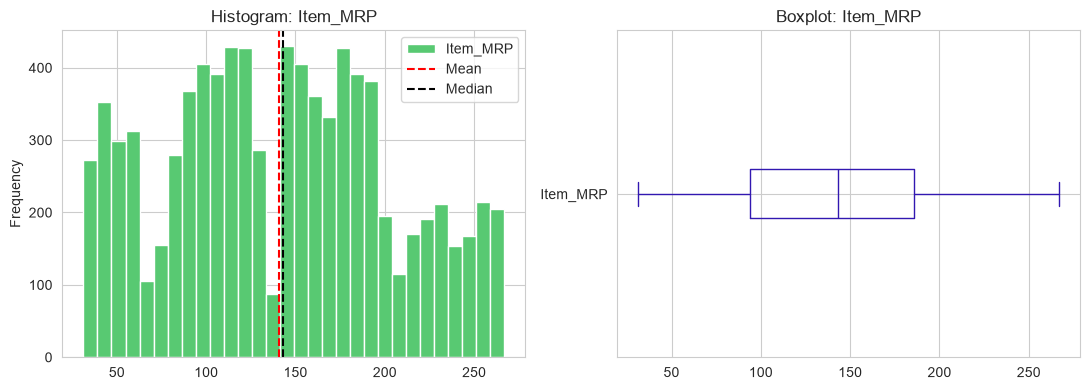

In [24]:
describe_quantitative("Item_MRP")

**Item_Outlet_Sales** - our main outcome variable. Notice here mean and median start to
drift apart, and mode is barely meaningful for a continuous variable like this (it just
happens to be whichever exact value repeated most, which carries little real information).
This is a hint the distribution is skewed, worth keeping in mind.


Mean           2181.29
Median         1794.33
Mode            958.75
Min              33.29
Q1              834.25
Q3             3101.30
Max           13086.96
Range         13053.67
Variance    2912140.94
Std Dev        1706.50
IQR            2267.05
dtype: float64

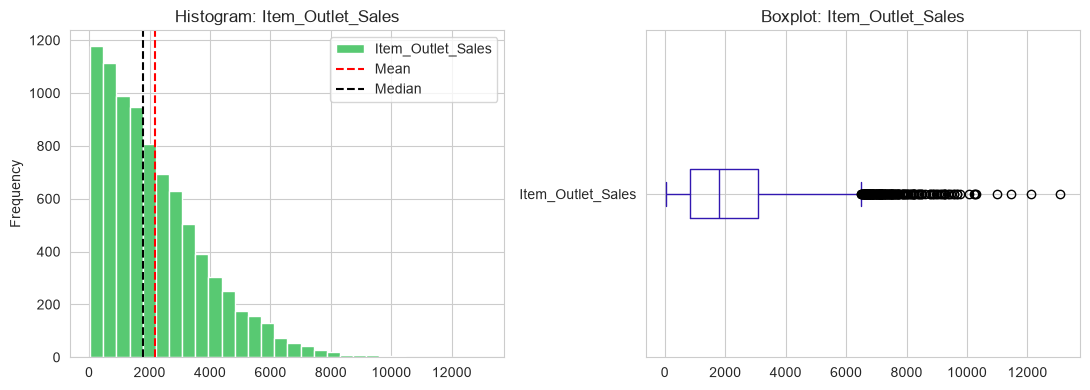

In [25]:
describe_quantitative("Item_Outlet_Sales")

### 4.1 Outlier Detection with Tukey's Method

Recall from the deck: any point beyond `Q1 - 1.5*IQR` (lower whisker) or
`Q3 + 1.5*IQR` (upper whisker) is flagged as an outlier.


In [26]:
def tukey_outliers(column):
    data = df[column]
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = data[(data < lower) | (data > upper)]
    print(f"{column}: lower bound = {lower:.2f}, upper bound = {upper:.2f}")
    print(f"Number of outliers: {len(outliers)} out of {len(data)} ({len(outliers)/len(data)*100:.2f}%)")
    return outliers

sales_outliers = tukey_outliers("Item_Outlet_Sales")

Item_Outlet_Sales: lower bound = -2566.33, upper bound = 6501.87
Number of outliers: 186 out of 8523 (2.18%)


### 4.2 Deciles and Percentiles

Quartiles split the data into 4 parts; deciles split it into 10. Let's compute the 9
deciles (D1-D9) for `Item_Outlet_Sales` to see finer detail than the five-number summary
alone gives us.


In [27]:
deciles = df["Item_Outlet_Sales"].quantile([i / 10 for i in range(1, 10)])
deciles.index = [f"D{i} (P{i*10})" for i in range(1, 10)]
deciles.round(2)

D1 (P10)     343.55
D2 (P20)     666.47
D3 (P30)    1022.67
D4 (P40)    1402.17
D5 (P50)    1794.33
D6 (P60)    2257.33
D7 (P70)    2805.81
D8 (P80)    3453.50
D9 (P90)    4570.05
Name: Item_Outlet_Sales, dtype: float64

## 5. Multivariate Analysis - Relationships Between Variables

So far we've looked at one variable at a time. Most real questions involve two variables,
for example: *"Do larger outlets generate higher sales?"*. Following the deck, we label
the two roles:

- **Explanatory variable (X)** - the one we think affects or predicts the outcome
- **Response variable (Y)** - the outcome itself

and classify the relationship by the type of each variable:

| | Response: Categorical | Response: Quantitative |
|---|---|---|
| **Explanatory: Categorical** | C -> C | C -> Q |
| **Explanatory: Quantitative** | Q -> C | Q -> Q |

We'll work through one example of each of the three most common cases: C->C, C->Q, and Q->Q.


### 5.1 C -> C Relationship: Outlet_Location_Type vs. Outlet_Type

Both variables are categorical. Question: *does the mix of store formats differ across
city tiers?* We summarize this with a **two-way table**, convert it to row-wise
percentages, and visualize with a **double bar chart** - exactly as in the deck's
Gender vs. Body-Image example.


In [28]:
two_way = pd.crosstab(df["Outlet_Location_Type"], df["Outlet_Type"])
two_way["Total"] = two_way.sum(axis=1)
two_way

Outlet_Type,Grocery Store,Supermarket Type1,Supermarket Type2,Supermarket Type3,Total
Outlet_Location_Type,,,,,
Tier 1,528,1860,0,0,2388
Tier 2,0,2785,0,0,2785
Tier 3,555,932,928,935,3350


In [29]:
row_pct = pd.crosstab(df["Outlet_Location_Type"], df["Outlet_Type"], normalize="index") * 100
row_pct.round(1)

Outlet_Type,Grocery Store,Supermarket Type1,Supermarket Type2,Supermarket Type3
Outlet_Location_Type,,,,
Tier 1,22.1,77.9,0.0,0.0
Tier 2,0.0,100.0,0.0,0.0
Tier 3,16.6,27.8,27.7,27.9


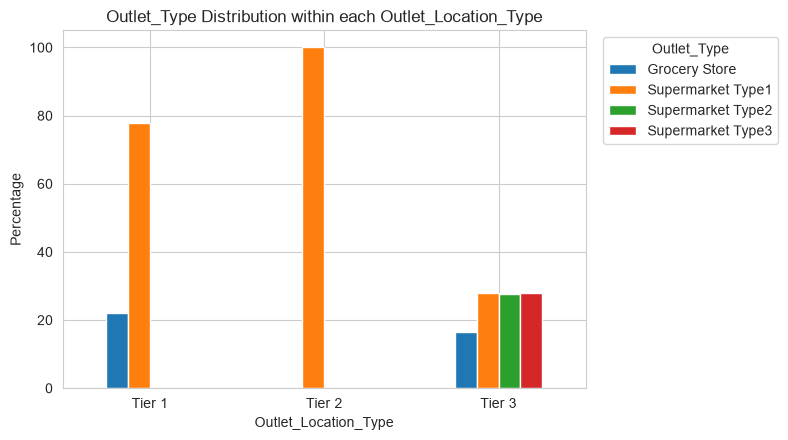

In [30]:
row_pct.plot(kind="bar", figsize=(8, 4.5))
plt.title("Outlet_Type Distribution within each Outlet_Location_Type")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Outlet_Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

Tier 1 and Tier 2 cities are almost entirely Supermarket Type1, while Tier 3 is the
only tier that also hosts Grocery Stores and the larger Supermarket Type2/3 formats -
a clear C -> C relationship.


### 5.2 C -> Q Relationship: Outlet_Type (explanatory) vs. Item_Outlet_Sales (response)

Here the explanatory variable is categorical and the response is quantitative. We compare
the *distribution* of sales within each category using a **five-number summary table** and
**side-by-side boxplots**, just like the SSHA-scores-by-gender example in the deck.


In [31]:
df.groupby("Outlet_Type")["Item_Outlet_Sales"].describe()[["min", "25%", "50%", "75%", "max"]].round(1)

,min,25%,50%,75%,max
Outlet_Type,,,,,
Grocery Store,33.3,153.8,257.0,458.7,1775.7
Supermarket Type1,73.2,1151.2,1990.7,3135.9,10256.6
Supermarket Type2,69.2,981.6,1655.2,2702.6,6768.5
Supermarket Type3,241.7,2044.3,3365.0,4975.5,13087.0


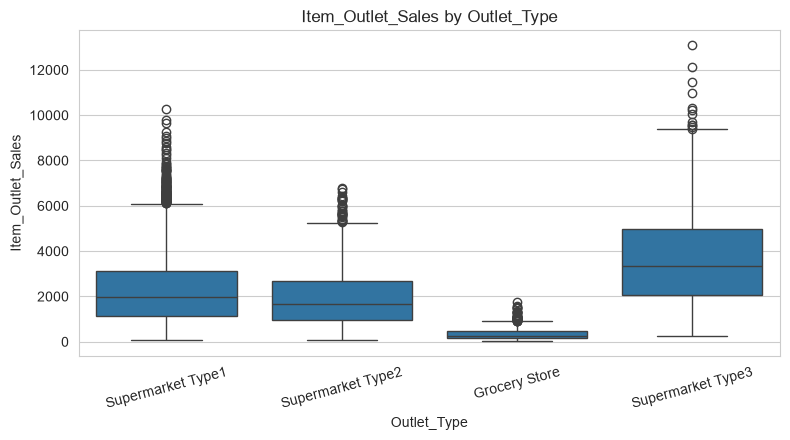

In [32]:
plt.figure(figsize=(8, 4.5))
sns.boxplot(data=df, x="Outlet_Type", y="Item_Outlet_Sales")
plt.title("Item_Outlet_Sales by Outlet_Type")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

Grocery Stores sell noticeably less per transaction than any Supermarket format, and
Supermarket Type3 has both the highest median sales and the widest spread - this is the
"gender effect on SSHA scores" idea applied to outlet format and sales.


### 5.3 Q -> Q Relationship: Item_MRP (explanatory) vs. Item_Outlet_Sales (response)

Both variables are quantitative. We start with a **scatterplot**, then quantify the
relationship with **covariance** and the **Pearson correlation coefficient (r)**, computed
two ways: first from the raw formula in the deck, then double-checked with pandas.


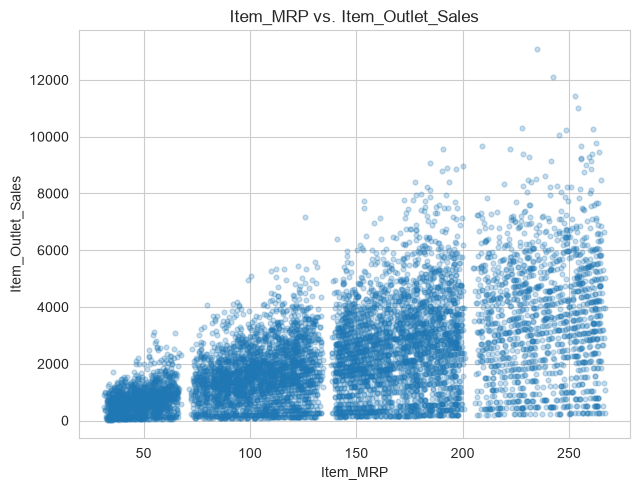

In [33]:
plt.figure(figsize=(6.5, 5))
plt.scatter(df["Item_MRP"], df["Item_Outlet_Sales"], alpha=0.25, s=12)
plt.xlabel("Item_MRP")
plt.ylabel("Item_Outlet_Sales")
plt.title("Item_MRP vs. Item_Outlet_Sales")
plt.tight_layout()
plt.show()

In [34]:
x = df["Item_MRP"]
y = df["Item_Outlet_Sales"]

cov_xy = ((x - x.mean()) * (y - y.mean())).mean()
r_manual = cov_xy / (x.std(ddof=0) * y.std(ddof=0))

print(f"Covariance (manual formula) : {cov_xy:.2f}")
print(f"Correlation r (manual)      : {r_manual:.3f}")
print(f"Correlation r (pandas .corr): {x.corr(y):.3f}")

Covariance (manual formula) : 60310.41
Correlation r (manual)      : 0.568
Correlation r (pandas .corr): 0.568


r is positive and moderately strong: higher-priced items tend to generate higher
sales value per transaction, following a roughly linear, positive pattern - the "direction,
form, strength" language from the deck.


We can extend this to a full **correlation matrix** across all quantitative variables
at once, visualized as a heatmap (the correlation matrix is just the covariance matrix with
each value rescaled to the -1 to +1 range).


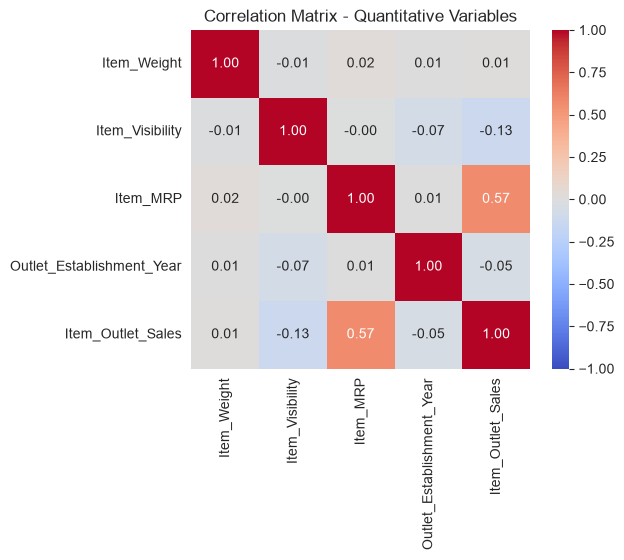

In [35]:
numeric_cols = ["Item_Weight", "Item_Visibility", "Item_MRP",
                "Outlet_Establishment_Year", "Item_Outlet_Sales"]
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(6.5, 5.5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Correlation Matrix - Quantitative Variables")
plt.tight_layout()
plt.show()

## 6. A Closing Note: Correlation Does Not Imply Causation

Suppose we noticed that outlets established in later years tend to have different average
sales than older outlets. It would be tempting to say *"the establishment year causes the
sales difference"*. But just like the firefighters/fire-damage example in the deck, there
could easily be a **lurking variable** here, for instance, newer outlets may systematically
have been opened with a particular `Outlet_Type` or `Outlet_Size` from the start, and it is
really that format/size (not the year itself) driving the sales difference.

Whenever we see an association between two variables in purely observational data like
this (no experiment, no random assignment of stores to formats), we should resist jumping
to a causal explanation without first checking for lurking variables.


## 7. Summary

In this notebook we:

1. Classified each variable as categorical/quantitative and nominal/ordinal/interval/ratio
2. Detected missing values in `Item_Weight` and `Outlet_Size`, checked the shape of the
   data to justify the choice, and imputed them with **median** and **mode** respectively
3. Cleaned inconsistent category labels in `Item_Fat_Content`
4. Described single categorical variables with frequency tables, bar charts, and pie charts
5. Described single quantitative variables with central tendency, dispersion, five-number
   summaries, boxplots, Tukey outlier detection, and deciles
6. Explored C->C, C->Q, and Q->Q relationships with two-way tables, grouped boxplots,
   scatterplots, covariance, and correlation
7. Closed with a reminder that correlation alone never establishes causation

This is the complete descriptive-statistics toolkit from the lecture deck, applied
end-to-end on a real dataset.
